In [29]:
import numpy
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn as nn

from torch.utils.data import random_split
from torch.utils.data import DataLoader

In [30]:
import torch

print(torch.__version__)
print("CUDA dostępna:", torch.cuda.is_available())
print("Wersja CUDA w torch:", torch.version.cuda)
print("Liczba GPU:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.11.0+cu128
CUDA dostępna: True
Wersja CUDA w torch: 12.8
Liczba GPU: 1
GPU: Tesla T4


In [31]:
torch.manual_seed(42)  # For reproducibility

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [32]:
from pathlib import Path

base = Path("/content/data/prepared_data256")

print("Czy istnieje base?", base.exists())
print("Czy istnieje images?", (base / "images").exists())
print("Czy istnieje masks?", (base / "masks").exists())

print("Pliki w base:")
print(list(base.glob("*")))

print("Pliki w images:")
print(list((base / "images").glob("*"))[:10])

print("Pliki w masks:")
print(list((base / "masks").glob("*"))[:10])

Czy istnieje base? True
Czy istnieje images? True
Czy istnieje masks? True
Pliki w base:
[PosixPath('/content/data/prepared_data256/masks'), PosixPath('/content/data/prepared_data256/images')]
Pliki w images:
[PosixPath('/content/data/prepared_data256/images/image_part_002_9.png'), PosixPath('/content/data/prepared_data256/images/image_part_009_51.png'), PosixPath('/content/data/prepared_data256/images/image_part_006_2.png'), PosixPath('/content/data/prepared_data256/images/image_part_003_51.png'), PosixPath('/content/data/prepared_data256/images/image_part_004_21.png'), PosixPath('/content/data/prepared_data256/images/image_part_004_0.png'), PosixPath('/content/data/prepared_data256/images/image_part_002_6.png'), PosixPath('/content/data/prepared_data256/images/image_part_008_6.png'), PosixPath('/content/data/prepared_data256/images/image_part_007_22.png'), PosixPath('/content/data/prepared_data256/images/image_part_001_1.png')]
Pliki w masks:
[PosixPath('/content/data/prepared_data25

In [33]:
from pathlib import Path
from sklearn.model_selection import train_test_split

images = sorted(Path("/content/data/prepared_data256/images").glob("*.png"))
masks = sorted(Path("/content/data/prepared_data256/masks").glob("*.png"))

pairs = list(zip(images, masks))

train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 352
Val: 76
Test: 76


In [34]:
import torch
import random
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torchvision.transforms.functional as TF

class SegmentationTransform():
    def __init__(self, hflip_prob=0.5, vflip_prob=0.5, max_rotation=15):
        self.hflip_prob = hflip_prob
        self.vflip_prob = vflip_prob
        self.max_rotation = max_rotation

    def __call__(self, image, mask):
        # Losowe odbicie poziome
        if random.random() < self.hflip_prob:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        # Losowe odbicie pionowe
        if random.random() < self.vflip_prob:
            image = TF.vflip(image)
            mask = TF.vflip(mask)

        # Losowy obrót obrazu i maski
        angle = random.uniform(-self.max_rotation, self.max_rotation)
        image = TF.rotate(image, angle)
        mask = TF.rotate(mask, angle)

        # Zmiany oświetlenia i kontrastu (tylko na zdjęciu, nie ruszamy maski!)
        image = TF.adjust_brightness(image, brightness_factor=random.uniform(0.8, 1.2))
        image = TF.adjust_contrast(image, contrast_factor=random.uniform(0.8, 1.2))

        return image, mask

class AerialSegemntationDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        image = TF.to_tensor(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)

        return image, mask

In [35]:
from torch.utils.data import DataLoader

# Tworzymy transformację dla zbioru treningowego
train_transform = SegmentationTransform(hflip_prob=0.5, vflip_prob=0.5, max_rotation=30)

train_dataset = AerialSegemntationDataset(train_pairs, transform=train_transform)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)

val_dataset = AerialSegemntationDataset(val_pairs, transform=None)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

test_dataset = AerialSegemntationDataset(test_pairs, transform=None)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

In [36]:
import torch
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, n_class, inuput_channels):
        super().__init__()
        # Encoding
        self.e11 = nn.Conv2d(inuput_channels, 64, kernel_size=3, padding=1, bias=False)
        self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False)
        self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False)
        self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False)

        # Decoding + Attention
        self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=512, F_l=512, F_int=256)
        self.d11 = nn.Conv2d(1024, 512, kernel_size=3, padding=1)
        self.d12 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.d21 = nn.Conv2d(512, 256, kernel_size=3, padding=1)
        self.d22 = nn.Conv2d(256, 256, kernel_size=3, padding=1)

        self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.d31 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.d32 = nn.Conv2d(128, 128, kernel_size=3, padding=1)

        self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.d41 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.d42 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # out
        self.outconv = nn.Conv2d(64, n_class, kernel_size=1)

    def forward(self, x):
        # encoder
        xe11 = nn.functional.relu(self.e11(x))
        xe12 = nn.functional.relu(self.e12(xe11))
        xp1 = self.pool1(xe12)

        xe21 = nn.functional.relu(self.e21(xp1))
        xe22 = nn.functional.relu(self.e22(xe21))
        xp2 = self.pool2(xe22)

        xe31 = nn.functional.relu(self.e31(xp2))
        xe32 = nn.functional.relu(self.e32(xe31))
        xp3 = self.pool3(xe32)

        xe41 = nn.functional.relu(self.e41(xp3))
        xe42 = nn.functional.relu(self.e42(xe41))
        xp4 = self.pool4(xe42)

        xe51 = nn.functional.relu(self.e51(xp4))
        xe52 = nn.functional.relu(self.e52(xe51))

        # decoder ze skip connection po Attention
        xu1 = self.upconv1(xe52)
        xatt1 = self.att1(g=xu1, x=xe42)
        xu11 = torch.cat([xu1, xatt1], dim=1)
        xd11 = nn.functional.relu(self.d11(xu11))
        xd12 = nn.functional.relu(self.d12(xd11))

        xu2 = self.upconv2(xd12)
        xatt2 = self.att2(g=xu2, x=xe32)
        xu21 = torch.cat([xu2, xatt2], dim=1)
        xd21 = nn.functional.relu(self.d21(xu21))
        xd22 = nn.functional.relu(self.d22(xd21))

        xu3 = self.upconv3(xd22)
        xatt3 = self.att3(g=xu3, x=xe22)
        xu31 = torch.cat([xu3, xatt3], dim=1)
        xd31 = nn.functional.relu(self.d31(xu31))
        xd32 = nn.functional.relu(self.d32(xd31))

        xu4 = self.upconv4(xd32)
        xatt4 = self.att4(g=xu4, x=xe12)
        xu41 = torch.cat([xu4, xatt4], dim=1)
        xd41 = nn.functional.relu(self.d41(xu41))
        xd42 = nn.functional.relu(self.d42(xd41))

        # out
        out = self.outconv(xd42)

        return out

In [37]:
import torch.nn.functional as F
from torchmetrics.classification import MulticlassJaccardIndex

class DiceCELoss(nn.Module):
    def __init__(self, ce_weight=0.5, dice_weight=0.5):
        super().__init__()
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        # Straty Cross Entropy
        ce_loss = self.ce(inputs, targets)

        # Straty Dice Loss
        inputs_softmax = F.softmax(inputs, dim=1)
        num_classes = inputs.shape[1]
        targets_one_hot = F.one_hot(targets, num_classes=num_classes).permute(0, 3, 1, 2).float()

        smooth = 1e-6
        intersection = (inputs_softmax * targets_one_hot).sum(dim=(2, 3))
        union = inputs_softmax.sum(dim=(2, 3)) + targets_one_hot.sum(dim=(2, 3))

        dice_score = (2. * intersection + smooth) / (union + smooth)
        dice_loss = 1.0 - dice_score.mean()

        return self.ce_weight * ce_loss + self.dice_weight * dice_loss

class Trainer():
    def __init__(self, model, train_loader, val_loader, test_loader, criterion, optimizer, num_epochs, scheduler=None, metric=None):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.num_epochs = num_epochs
        self.scheduler = scheduler
        self.metric = metric.to(device=device)

        self.train_loss_hist = []
        self.val_loss_hist = []
        self.train_miou_hist = []
        self.val_miou_hist = []

    def training_epoch(self, data_loader):
        self.model.train()
        running_loss = 0.0

        self.metric.reset()
        for image, mask in data_loader:
            image, mask = image.to(device), mask.to(device)

            self.optimizer.zero_grad()
            out = self.model(image)
            loss = self.criterion(out, mask)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            pred = torch.argmax(out, dim=1)
            self.metric.update(pred, mask)

        loss = running_loss/len(data_loader)
        miou = self.metric.compute()
        return loss, miou.mean().item()

    def evaluate(self, data_loader):
        self.model.eval()
        running_loss = 0.0
        self.metric.reset()

        with torch.no_grad():
            for image, mask in data_loader:
                image, mask = image.to(device), mask.to(device)
                out = self.model(image)
                loss = self.criterion(out, mask)

                running_loss += loss.item()
                pred = torch.argmax(out, dim=1)
                self.metric.update(pred, mask)

        loss = running_loss/len(data_loader)
        miou = self.metric.compute()
        return loss, miou.mean().item()

    def train(self):
        for epoch in range(self.num_epochs):
            train_loss, train_miou = self.training_epoch(self.train_loader)
            val_loss, val_miou = self.evaluate(self.val_loader)

            # Krok schedulera - obniży lr jeśli straty walidacyjne się nie poprawiają
            if self.scheduler is not None:
                self.scheduler.step(val_loss)

            self.train_loss_hist.append(train_loss)
            self.val_loss_hist.append(val_loss)
            self.train_miou_hist.append(train_miou)
            self.val_miou_hist.append(val_miou)

            print(f'Epoch [{epoch + 1}/{self.num_epochs}], '
                  f'Train Loss: {train_loss:.4f}, val loss: {val_loss:.4f} '
                  f'Train miou: {train_miou:.4f}, val miou: {val_miou:.4f}')

    def show_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].plot(range(self.num_epochs), np.array(self.train_loss_hist), color='blue', label='Train Loss')
        axes[0].plot(range(self.num_epochs), np.array(self.val_loss_hist), color='red', label='Val Loss')
        axes[0].set_title("Trening: Funkcja straty")
        axes[0].set_xlabel("epoch")
        axes[0].set_ylabel("loss")
        axes[0].legend()

        axes[1].plot(range(self.num_epochs), np.array(self.train_miou_hist), color='blue', label='Train mIoU')
        axes[1].plot(range(self.num_epochs), np.array(self.val_miou_hist), color='red', label='Val mIoU')
        axes[1].set_title("Trening: miou")
        axes[1].set_xlabel("epoch")
        axes[1].set_ylabel("mIoU")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

    def get_history(self):
        return self.train_loss_hist, self.val_loss_hist, self.train_miou_hist, self.val_miou_hist

In [38]:
# Inicjalizacja modelu
modelUnet = AttentionUNet(n_class=6, inuput_channels=3).to(device)

# Optymalizator
optimizer = optim.Adam(modelUnet.parameters(), lr=0.001)

# Inicjalizacja harmonogramu
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Połączona funkcja straty
criterion = DiceCELoss(ce_weight=0.5, dice_weight=0.5)

UNet_Aerial_trainer = Trainer(model=modelUnet,
                              train_loader=train_loader,
                              val_loader=val_loader,
                              test_loader=test_loader,
                              criterion=criterion,
                              optimizer=optimizer,
                              num_epochs=50,
                              scheduler=scheduler,
                              metric=MulticlassJaccardIndex(num_classes=6, average=None))
UNet_Aerial_trainer.train()

Epoch [1/50], Train Loss: 1.0842, val loss: 0.9677 Train miou: 0.1422, val miou: 0.1065
Epoch [2/50], Train Loss: 0.8651, val loss: 0.8898 Train miou: 0.1849, val miou: 0.1696
Epoch [3/50], Train Loss: 0.8805, val loss: 0.8997 Train miou: 0.1876, val miou: 0.1481
Epoch [4/50], Train Loss: 0.8120, val loss: 0.9092 Train miou: 0.2414, val miou: 0.2015
Epoch [5/50], Train Loss: 0.7904, val loss: 0.8187 Train miou: 0.2670, val miou: 0.2404
Epoch [6/50], Train Loss: 0.7664, val loss: 0.7902 Train miou: 0.2764, val miou: 0.2359
Epoch [7/50], Train Loss: 0.7606, val loss: 0.9390 Train miou: 0.2845, val miou: 0.2179
Epoch [8/50], Train Loss: 0.7598, val loss: 0.7885 Train miou: 0.2874, val miou: 0.2547
Epoch [9/50], Train Loss: 0.7506, val loss: 0.7874 Train miou: 0.2908, val miou: 0.2598
Epoch [10/50], Train Loss: 0.7506, val loss: 0.7959 Train miou: 0.2932, val miou: 0.2547
Epoch [11/50], Train Loss: 0.7250, val loss: 0.7769 Train miou: 0.3549, val miou: 0.3725
Epoch [12/50], Train Loss: 0.7

In [39]:
# Zapis modelu po zakończeniu treningu

import torch
import os

os.makedirs("saved_models", exist_ok=True)

MODEL_PATH = "saved_models/attention_unet_aerial_model.pth"

torch.save(modelUnet.state_dict(), MODEL_PATH)

print(f"Model zapisany do: {MODEL_PATH}")

Model zapisany do: saved_models/attention_unet_aerial_model.pth


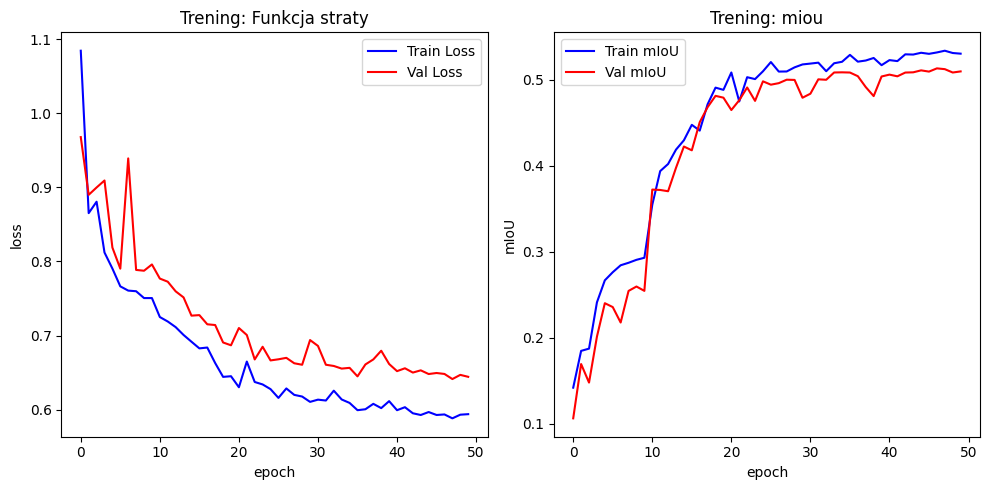

In [40]:
UNet_Aerial_trainer.show_history()

In [41]:
modelUnet.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = modelUnet(images)          # [B, 6, H, W]
    preds = torch.argmax(logits, dim=1) # [B, H, W]

print("images:", images.shape)
print("masks:", masks.shape)
print("logits:", logits.shape)
print("preds:", preds.shape)

print("Mask unique:", masks.unique())
print("Pred unique:", preds.unique())

images: torch.Size([8, 3, 256, 256])
masks: torch.Size([8, 256, 256])
logits: torch.Size([8, 6, 256, 256])
preds: torch.Size([8, 256, 256])
Mask unique: tensor([0, 1, 2, 3, 5], device='cuda:0')
Pred unique: tensor([0, 1, 2, 3, 4], device='cuda:0')


In [42]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_COLORS = {
    0: (60, 16, 152),     # Building
    1: (132, 41, 246),    # Land
    2: (110, 193, 228),   # Road
    3: (254, 221, 58),    # Vegetation
    4: (226, 169, 41),    # Water
    5: (155, 155, 155),   # Unlabeled
}


def class_mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_idx, color in CLASS_COLORS.items():
        rgb[mask == class_idx] = color

    return rgb

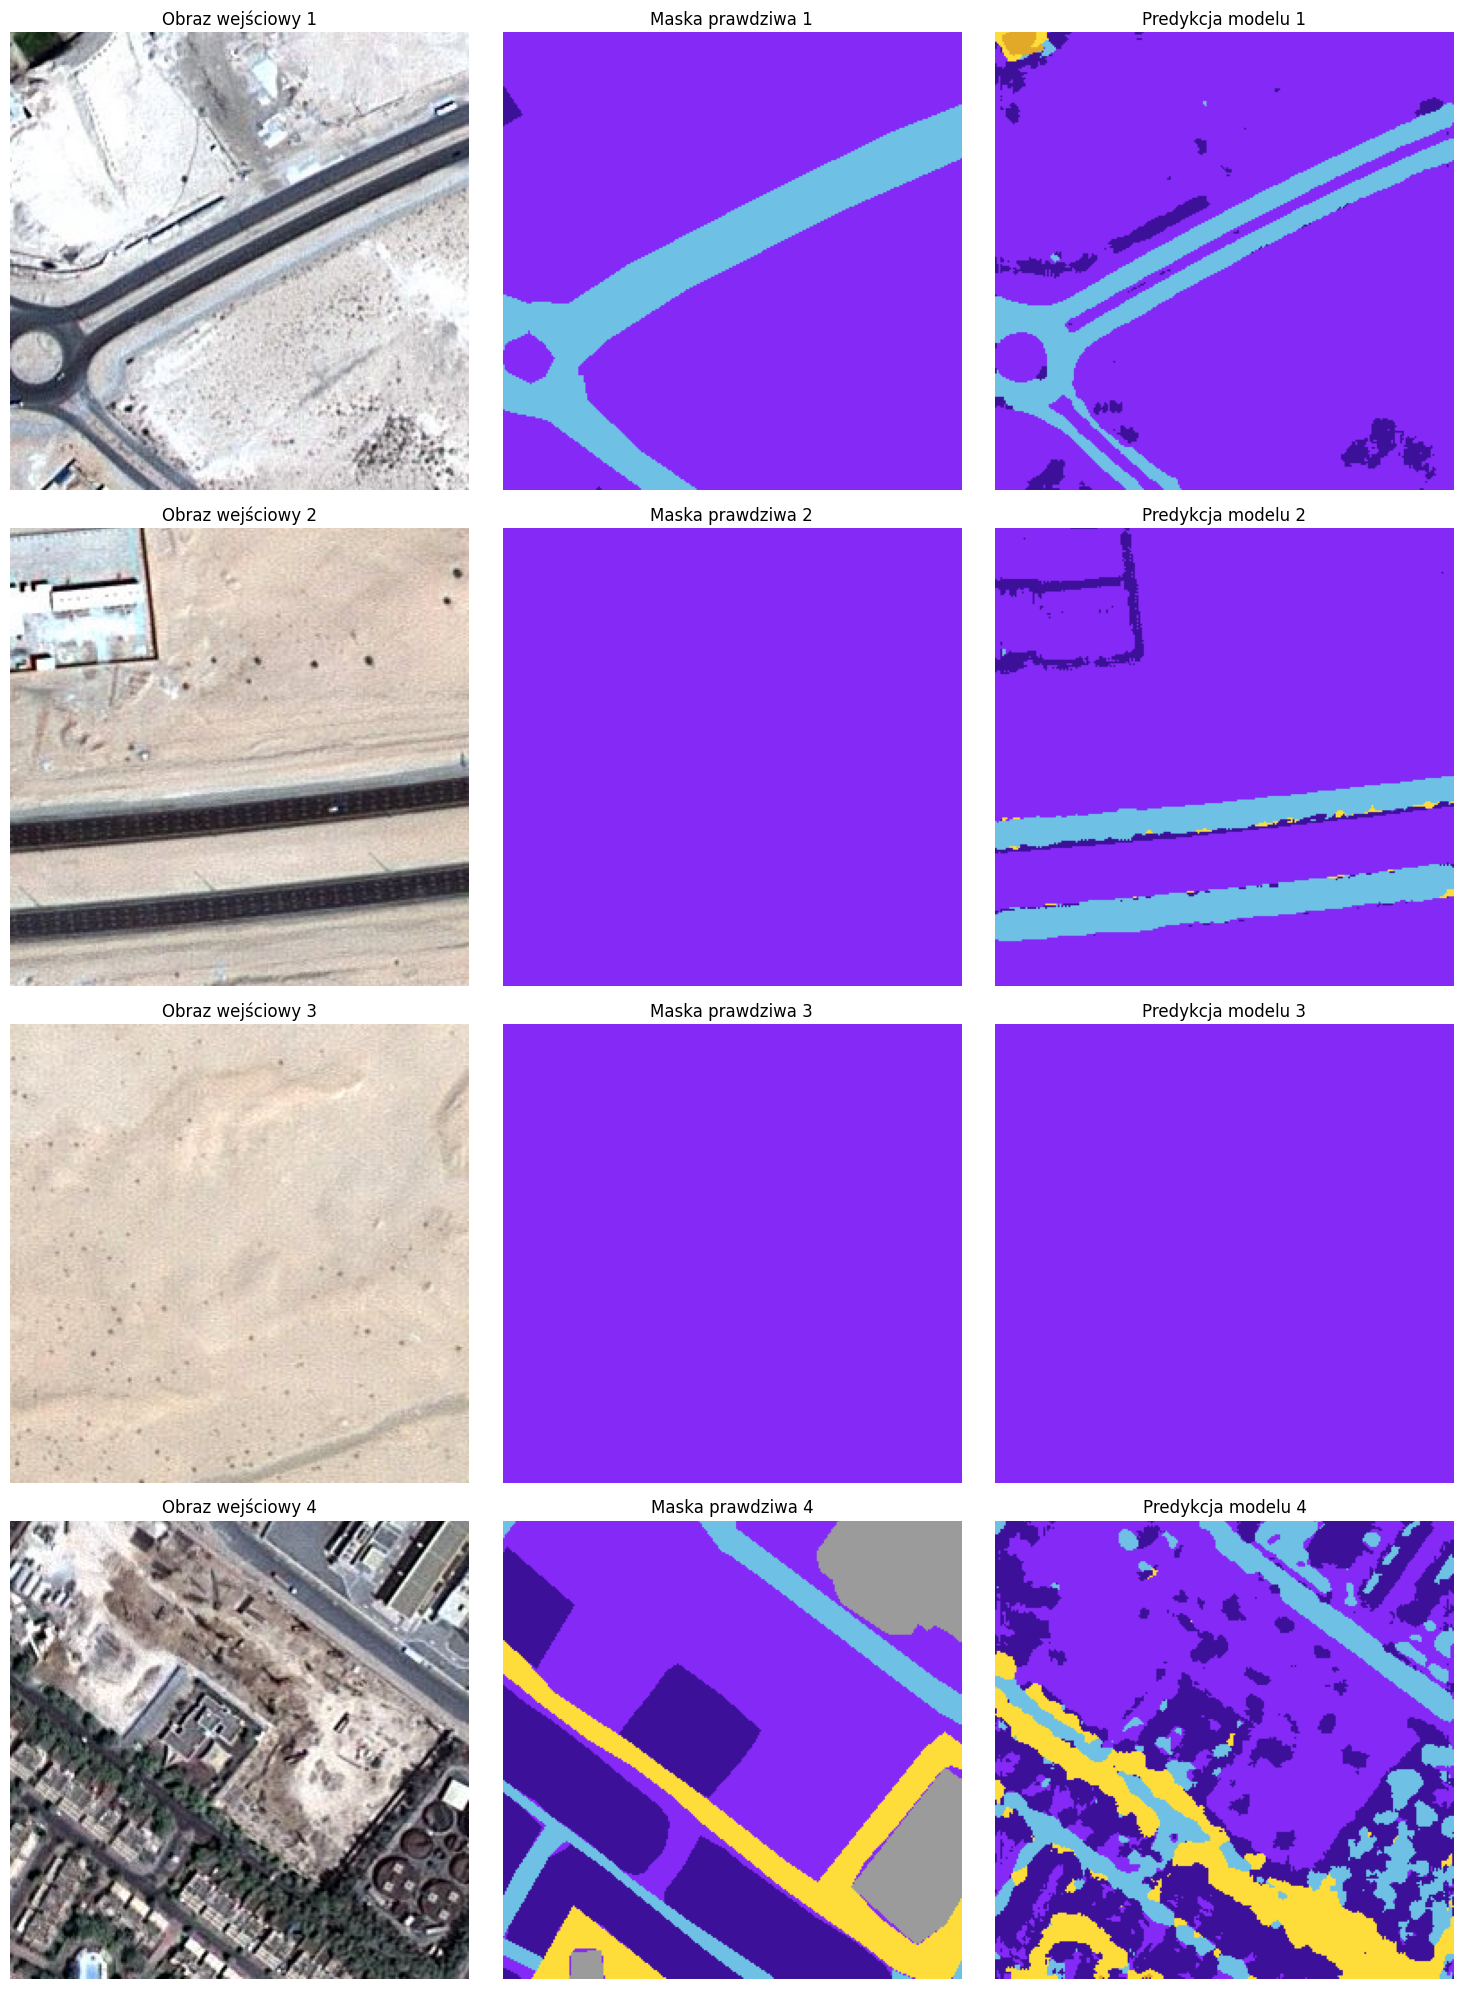

In [45]:
num_images_to_show = 4

num_images_to_show = min(num_images_to_show, images.shape[0])

# Tworzymy siatkę wykresów: liczba wierszy to num_images_to_show, 3 kolumny
fig, axes = plt.subplots(num_images_to_show, 3, figsize=(15, 5 * num_images_to_show))

if num_images_to_show == 1:
    axes = [axes]

for i in range(num_images_to_show):
    # Przetwarzanie tensorów na numpy arrays dla i-tego obrazu
    image_np = images[i].detach().cpu().permute(1, 2, 0).numpy()
    mask_np = masks[i].detach().cpu().numpy()
    pred_np = preds[i].detach().cpu().numpy()

    # Konwersja klas na kolory RGB
    mask_rgb = class_mask_to_rgb(mask_np)
    pred_rgb = class_mask_to_rgb(pred_np)

    # Obraz wejściowy
    axes[i][0].imshow(image_np)
    axes[i][0].set_title(f"Obraz wejściowy {i+1}")
    axes[i][0].axis("off")

    # Maska prawdziwa
    axes[i][1].imshow(mask_rgb)
    axes[i][1].set_title(f"Maska prawdziwa {i+1}")
    axes[i][1].axis("off")

    # Predykcja modelu
    axes[i][2].imshow(pred_rgb)
    axes[i][2].set_title(f"Predykcja modelu {i+1}")
    axes[i][2].axis("off")

# Dopasowanie odstępów między wykresami, żeby tytuły na siebie nie nachodziły
plt.tight_layout()
plt.show()

=== Podsumowanie metryk na zbiorze testowym ===


,Metryka,Wartość
0,Loss,0.587542
1,Pixel accuracy,0.792953
2,Mean pixel accuracy,0.765798
3,Mean precision,0.785725
4,Mean recall,0.765798
5,Mean specificity,0.937569
6,Mean F1 / Dice,0.774902
7,Mean IoU,0.642141
8,Weighted F1 / Dice,0.794924
9,Weighted IoU,0.668422


=== Metryki dla poszczególnych klas ===


,Klasa,Piksele GT,Piksele przewidziane,Udział GT [%],Pixel accuracy,Precision,Recall,Specificity,F1 / Dice,IoU / Jaccard
0,Building,939063,989341,18.853900,0.688549,0.653557,0.688549,0.915196,0.670597,0.504435
1,Land,2542209,2640757,51.040830,0.888384,0.855231,0.888384,0.843225,0.871492,0.772252
2,Road,536267,513238,10.766822,0.670910,0.701014,0.670910,0.965474,0.685632,0.521644
3,Vegetation,783139,698656,15.723359,0.710908,0.796873,0.710908,0.966191,0.751440,0.601845
4,Water,146988,138744,2.951130,0.870241,0.921950,0.870241,0.997760,0.895349,0.810527
5,Unlabeled,33070,0,0.663958,0.000000,NaN,0.000000,1.000000,0.000000,0.000000


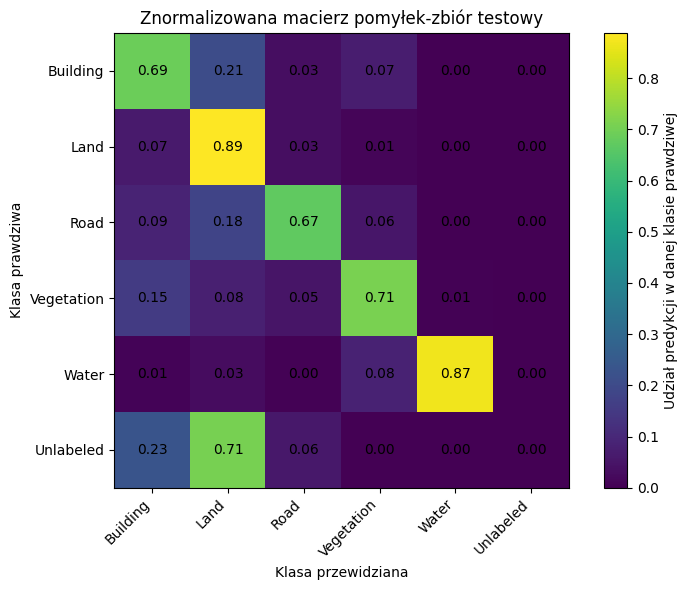

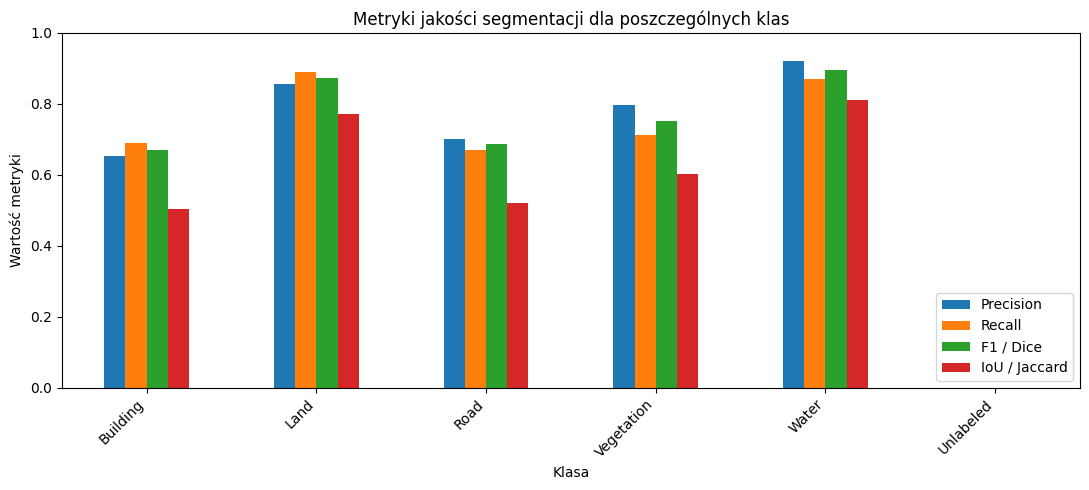

Zapisano pliki:
- metryki_podsumowanie_test.csv
- metryki_klasy_test.csv


In [46]:
# =========================
# Pełna ocena modelu na zbiorze testowym
# =========================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

CLASS_NAMES = {
    0: "Building",
    1: "Land",
    2: "Road",
    3: "Vegetation",
    4: "Water",
    5: "Unlabeled",
}

NUM_CLASSES = 6

IGNORE_CLASS_FOR_MEAN = 5


def safe_divide(numerator, denominator):
    """Dzielenie odporne na dzielenie przez zero; zwraca NaN tam, gdzie mianownik = 0."""
    numerator = np.asarray(numerator, dtype=np.float64)
    denominator = np.asarray(denominator, dtype=np.float64)
    return np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=np.float64),
        where=denominator != 0
    )


def evaluate_segmentation_model(
    model,
    data_loader,
    num_classes=6,
    class_names=None,
    criterion=None,
    device=None,
    ignore_class_for_mean=None,
):
    """
    Liczy metryki dla segmentacji semantycznej:
    - loss,
    - pixel accuracy,
    - mean pixel accuracy,
    - precision,
    - recall,
    - specificity,
    - F1/Dice,
    - IoU/Jaccard,
    - mean IoU,
    - frequency weighted IoU,
    - macierz pomyłek.
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    confusion_matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    total_loss = 0.0
    number_of_batches = 0

    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            if criterion is not None:
                loss = criterion(logits, masks)
                total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            # Spłaszczenie masek i predykcji: [B, H, W] -> [B*H*W]
            true = masks.detach().view(-1).cpu()
            pred = preds.detach().view(-1).cpu()

            # Zabezpieczenie: liczymy tylko piksele o etykietach 0..num_classes-1
            valid = (true >= 0) & (true < num_classes)
            true = true[valid]
            pred = pred[valid]

            # Wiersze = klasa prawdziwa, kolumny = klasa przewidziana
            encoded = num_classes * true + pred
            confusion_matrix += torch.bincount(
                encoded,
                minlength=num_classes ** 2
            ).reshape(num_classes, num_classes)

            number_of_batches += 1

    cm = confusion_matrix.numpy().astype(np.float64)

    total_pixels = cm.sum()
    tp = np.diag(cm)
    support = cm.sum(axis=1)       # ile pikseli naprawdę należy do danej klasy
    predicted = cm.sum(axis=0)     # ile pikseli model przypisał do danej klasy

    fp = predicted - tp
    fn = support - tp
    tn = total_pixels - tp - fp - fn

    pixel_accuracy = float(safe_divide(tp.sum(), total_pixels))

    expected_accuracy = float(safe_divide(np.sum(support * predicted), total_pixels ** 2))
    cohen_kappa = float(safe_divide(pixel_accuracy - expected_accuracy, 1 - expected_accuracy))

    class_accuracy = safe_divide(tp, support)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    f1_dice = safe_divide(2 * tp, 2 * tp + fp + fn)
    iou = safe_divide(tp, tp + fp + fn)

    valid_classes_for_mean = support > 0
    if ignore_class_for_mean is not None:
        valid_classes_for_mean[ignore_class_for_mean] = False

    mean_pixel_accuracy = np.nanmean(class_accuracy[valid_classes_for_mean])
    mean_precision = np.nanmean(precision[valid_classes_for_mean])
    mean_recall = np.nanmean(recall[valid_classes_for_mean])
    mean_specificity = np.nanmean(specificity[valid_classes_for_mean])
    mean_f1_dice = np.nanmean(f1_dice[valid_classes_for_mean])
    mean_iou = np.nanmean(iou[valid_classes_for_mean])

    class_frequency = safe_divide(support, total_pixels)
    frequency_weighted_iou = np.nansum(class_frequency[valid_classes_for_mean] * iou[valid_classes_for_mean])

    weighted_f1_dice = np.nansum(
        safe_divide(support[valid_classes_for_mean], support[valid_classes_for_mean].sum())
        * f1_dice[valid_classes_for_mean]
    )

    weighted_iou = np.nansum(
        safe_divide(support[valid_classes_for_mean], support[valid_classes_for_mean].sum())
        * iou[valid_classes_for_mean]
    )

    average_loss = None
    if criterion is not None and number_of_batches > 0:
        average_loss = total_loss / number_of_batches

    labels = [
        class_names.get(i, f"Klasa {i}") if class_names is not None else f"Klasa {i}"
        for i in range(num_classes)
    ]

    per_class_df = pd.DataFrame({
        "Klasa": labels,
        "Piksele GT": support.astype(np.int64),
        "Piksele przewidziane": predicted.astype(np.int64),
        "Udział GT [%]": safe_divide(support, total_pixels) * 100,
        "Pixel accuracy": class_accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1 / Dice": f1_dice,
        "IoU / Jaccard": iou,
    })

    summary_df = pd.DataFrame({
        "Metryka": [
            "Loss",
            "Pixel accuracy",
            "Mean pixel accuracy",
            "Mean precision",
            "Mean recall",
            "Mean specificity",
            "Mean F1 / Dice",
            "Mean IoU",
            "Weighted F1 / Dice",
            "Weighted IoU",
            "Frequency weighted IoU",
            "Cohen kappa",
        ],
        "Wartość": [
            average_loss,
            pixel_accuracy,
            mean_pixel_accuracy,
            mean_precision,
            mean_recall,
            mean_specificity,
            mean_f1_dice,
            mean_iou,
            weighted_f1_dice,
            weighted_iou,
            frequency_weighted_iou,
            cohen_kappa,
        ]
    })

    return per_class_df, summary_df, cm


# Liczenie metryk na zbiorze testowym
loss_function = nn.CrossEntropyLoss()

per_class_metrics, summary_metrics, confusion_matrix = evaluate_segmentation_model(
    model=modelUnet,
    data_loader=test_loader,
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    criterion=loss_function,
    device=device,
    ignore_class_for_mean=IGNORE_CLASS_FOR_MEAN,
)

print("=== Podsumowanie metryk na zbiorze testowym ===")
display(summary_metrics)

print("=== Metryki dla poszczególnych klas ===")
display(per_class_metrics)


# =========================
# Macierz pomyłek
# =========================

labels = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Normalizacja po wierszach, czyli względem klas prawdziwych
row_sums = confusion_matrix.sum(axis=1, keepdims=True)
confusion_matrix_normalized = np.divide(
    confusion_matrix,
    row_sums,
    out=np.zeros_like(confusion_matrix, dtype=np.float64),
    where=row_sums != 0
)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix_normalized)
plt.title("Znormalizowana macierz pomyłek-zbiór testowy")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa prawdziwa")
plt.xticks(range(NUM_CLASSES), labels, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), labels)
plt.colorbar(label="Udział predykcji w danej klasie prawdziwej")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, f"{confusion_matrix_normalized[i, j]:.2f}",
                 ha="center", va="center")

plt.tight_layout()
plt.show()


# =========================
# Wykres najważniejszych metryk klasowych
# =========================

plot_df = per_class_metrics.set_index("Klasa")[["Precision", "Recall", "F1 / Dice", "IoU / Jaccard"]]

ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_title("Metryki jakości segmentacji dla poszczególnych klas")
ax.set_xlabel("Klasa")
ax.set_ylabel("Wartość metryki")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# =========================
# Zapis wyników do plików CSV
# =========================

summary_metrics.to_csv("metryki_podsumowanie_test.csv", index=False)
per_class_metrics.to_csv("metryki_klasy_test.csv", index=False)

print("Zapisano pliki:")
print("- metryki_podsumowanie_test.csv")
print("- metryki_klasy_test.csv")
